In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from pathlib import Path

from config import Config
import data

In [111]:
import geopandas as gpd

data_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/multigraph")
fig_dir = data_dir / "_figures"
matchups = gpd.read_parquet(data_dir / "metadata" / "All_MERIT_matchups.parquet").set_index('comid')
matchups.index = matchups.index.astype(str)
matchups['outlet'] = gpd.GeoSeries.from_wkt(matchups['outlet'])
matchups

,outlet,outlet_id,total_area,unitarea,reservoir,custom,reach_id,sword_area,sword_distance,lake_reach_ids,...,longitude,min_date,max_date,min_discharge,max_discharge,mean_discharge,count_discharge,provider,hybas_area_diff,geometry
comid,,,,,,,,,,,,,,,,,,,,,
21000001,POINT (5.88917 47.94917),EAUF-V7200010,398.5,152.9,False,False,NaN,NaN,NaN,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,-0.034201,"MULTIPOLYGON (((5.93875 47.99125, 5.93708 47.9..."
21000012,POINT (5.88917 47.94917),EAUF-V7200010,324.8,194.6,False,False,NaN,NaN,NaN,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,0.053341,"MULTIPOLYGON (((5.79042 48.01125, 5.79042 48.0..."
21000019,POINT (5.685 47.53417),EAUF-V7200010,5173.0,242.5,False,False,2.160280e+10,4530.071328,0.0,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,-0.007977,"MULTIPOLYGON (((5.76042 47.56125, 5.76042 47.5..."
21000021,POINT (5.76917 47.58083),EAUF-V7200010,4758.7,8.4,False,False,2.160280e+10,4278.612301,0.0,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,0.003021,"MULTIPOLYGON (((5.80625 47.60125, 5.80708 47.6..."
21000022,POINT (5.80417 47.57),EAUF-V7200010,4506.6,68.9,False,False,2.160280e+10,4278.612301,0.0,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,0.009101,"MULTIPOLYGON (((5.85875 47.57458, 5.85875 47.5..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USGS-410401112134801,POINT (-112.1875 41.0625),USGS-410401112134801,9900.3,296.5,False,True,NaN,NaN,NaN,[],...,-112.230256,2003-10-01,2025-09-08,0.006230,45.873291,11.263905,7165.0,usgs,-0.002093,"MULTIPOLYGON (((-112.21458 40.96042, -112.2154..."
USGS-50035000,POINT (-66.4592 18.3217),USGS-50037000,345.7,345.7,False,True,NaN,NaN,NaN,[],...,-66.459568,1950-01-01,2025-09-08,0.240693,1857.585136,7.406389,25691.0,usgs,-0.091982,"MULTIPOLYGON (((-66.49208 18.29625, -66.49208 ..."
USGS-50037000,POINT (-66.5 18.3983),USGS-50037000,429.1,83.4,False,True,NaN,NaN,NaN,[],...,-66.496560,2019-06-13,2025-09-08,1.265763,911.802460,11.017469,2247.0,usgs,0.167805,"MULTIPOLYGON (((-66.50125 18.33125, -66.50125 ..."


In [4]:
run_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/cached_multigraph/era5_swot_glows_20251009_032132")
results = pd.read_parquet(run_dir / 'results' / 'test_results.parquet')
results

Type                                           obs        pred
Feature                                  discharge   discharge
basin          subbasin       date                            
USGS-02428400  73011033       2023-01-14       NaN  270.050018
               73011035       2023-01-14       NaN   47.630356
               73011044       2023-01-14       NaN   20.895082
               73011045       2023-01-14       NaN   62.892376
               73011109       2023-01-14       NaN   61.054600
...                                            ...         ...
USGS-01589035  USGS-01589035  2020-07-26  2.038813    3.987706
ABOM-281030010 ABOM-281030010 2023-03-24  0.094000    0.278067
ABOM-224727010 ABOM-224727010 2024-03-01  0.006000    0.015271
ABOM-132541010 ABOM-132541010 2024-02-02  4.341001    6.984094
USGS-12048000  USGS-12048000  2021-08-20  3.737824    6.027794

[8730990 rows x 2 columns]

In [112]:
basins_w_swot = matchups.dropna(subset='reach_id')['outlet_id'].unique()
matchups = matchups[matchups['outlet_id'].isin(basins_w_swot)]
matchups

,outlet,outlet_id,total_area,unitarea,reservoir,custom,reach_id,sword_area,sword_distance,lake_reach_ids,...,longitude,min_date,max_date,min_discharge,max_discharge,mean_discharge,count_discharge,provider,hybas_area_diff,geometry
comid,,,,,,,,,,,,,,,,,,,,,
21000001,POINT (5.88917 47.94917),EAUF-V7200010,398.5,152.9,False,False,NaN,NaN,NaN,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,-0.034201,"MULTIPOLYGON (((5.93875 47.99125, 5.93708 47.9..."
21000012,POINT (5.88917 47.94917),EAUF-V7200010,324.8,194.6,False,False,NaN,NaN,NaN,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,0.053341,"MULTIPOLYGON (((5.79042 48.01125, 5.79042 48.0..."
21000019,POINT (5.685 47.53417),EAUF-V7200010,5173.0,242.5,False,False,2.160280e+10,4530.071328,0.0,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,-0.007977,"MULTIPOLYGON (((5.76042 47.56125, 5.76042 47.5..."
21000021,POINT (5.76917 47.58083),EAUF-V7200010,4758.7,8.4,False,False,2.160280e+10,4278.612301,0.0,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,0.003021,"MULTIPOLYGON (((5.80625 47.60125, 5.80708 47.6..."
21000022,POINT (5.80417 47.57),EAUF-V7200010,4506.6,68.9,False,False,2.160280e+10,4278.612301,0.0,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,0.009101,"MULTIPOLYGON (((5.85875 47.57458, 5.85875 47.5..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USGS-393109104464500,POINT (-104.78 39.525),USGS-07374525,752.7,316.8,False,True,NaN,NaN,NaN,[],...,-104.779697,1991-10-01,2025-09-08,0.012176,23.729517,0.336421,12395.0,usgs,-0.002261,"MULTIPOLYGON (((-104.79958 39.50292, -104.7995..."
USGS-394220106431500,POINT (-106.7683 39.6775),USGS-09522000,1844.1,340.5,False,True,7.728080e+10,2110.051796,0.0,[],...,-106.725833,2006-04-29,2025-09-08,1.081704,161.972363,13.388783,7072.0,usgs,-0.054879,"MULTIPOLYGON (((-106.70125 39.62958, -106.7012..."
USGS-402114105350101,POINT (-105.6525 40.35),USGS-07374525,88.2,88.2,False,True,NaN,NaN,NaN,[],...,-105.584139,1995-10-01,2025-09-08,0.015008,21.549120,1.550812,9640.0,usgs,0.149974,"MULTIPOLYGON (((-105.77875 40.43375, -105.7737..."


In [115]:
train_basins = pd.read_csv(data_dir / 'basin_lists' / 'train_8020_swot.txt', header=None)[0].to_list()
matchups['train'] = False
matchups.loc[matchups['outlet_id'].isin(train_basins),'train'] = True
matchups

/nas/cee-water/cjgleason/ted/swot-ml/.venv/lib/python3.11/site-packages/geopandas/geodataframe.py:1968: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,outlet,outlet_id,total_area,unitarea,reservoir,custom,reach_id,sword_area,sword_distance,lake_reach_ids,...,min_date,max_date,min_discharge,max_discharge,mean_discharge,count_discharge,provider,hybas_area_diff,geometry,train
comid,,,,,,,,,,,,,,,,,,,,,
21000001,POINT (5.88917 47.94917),EAUF-V7200010,398.5,152.9,False,False,NaN,NaN,NaN,[],...,NaT,NaT,NaN,NaN,NaN,NaN,None,-0.034201,"MULTIPOLYGON (((5.93875 47.99125, 5.93708 47.9...",True
21000012,POINT (5.88917 47.94917),EAUF-V7200010,324.8,194.6,False,False,NaN,NaN,NaN,[],...,NaT,NaT,NaN,NaN,NaN,NaN,None,0.053341,"MULTIPOLYGON (((5.79042 48.01125, 5.79042 48.0...",True
21000019,POINT (5.685 47.53417),EAUF-V7200010,5173.0,242.5,False,False,2.160280e+10,4530.071328,0.0,[],...,NaT,NaT,NaN,NaN,NaN,NaN,None,-0.007977,"MULTIPOLYGON (((5.76042 47.56125, 5.76042 47.5...",True
21000021,POINT (5.76917 47.58083),EAUF-V7200010,4758.7,8.4,False,False,2.160280e+10,4278.612301,0.0,[],...,NaT,NaT,NaN,NaN,NaN,NaN,None,0.003021,"MULTIPOLYGON (((5.80625 47.60125, 5.80708 47.6...",True
21000022,POINT (5.80417 47.57),EAUF-V7200010,4506.6,68.9,False,False,2.160280e+10,4278.612301,0.0,[],...,NaT,NaT,NaN,NaN,NaN,NaN,None,0.009101,"MULTIPOLYGON (((5.85875 47.57458, 5.85875 47.5...",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USGS-393109104464500,POINT (-104.78 39.525),USGS-07374525,752.7,316.8,False,True,NaN,NaN,NaN,[],...,1991-10-01,2025-09-08,0.012176,23.729517,0.336421,12395.0,usgs,-0.002261,"MULTIPOLYGON (((-104.79958 39.50292, -104.7995...",True
USGS-394220106431500,POINT (-106.7683 39.6775),USGS-09522000,1844.1,340.5,False,True,7.728080e+10,2110.051796,0.0,[],...,2006-04-29,2025-09-08,1.081704,161.972363,13.388783,7072.0,usgs,-0.054879,"MULTIPOLYGON (((-106.70125 39.62958, -106.7012...",True
USGS-402114105350101,POINT (-105.6525 40.35),USGS-07374525,88.2,88.2,False,True,NaN,NaN,NaN,[],...,1995-10-01,2025-09-08,0.015008,21.549120,1.550812,9640.0,usgs,0.149974,"MULTIPOLYGON (((-105.77875 40.43375, -105.7737...",True


In [117]:
outlets = matchups[matchups.index == matchups['outlet_id']].set_geometry('outlet')

gauges = matchups.dropna(subset='provider')
gauges = gauges.set_geometry('outlet')
gauges

,outlet,outlet_id,total_area,unitarea,reservoir,custom,reach_id,sword_area,sword_distance,lake_reach_ids,...,min_date,max_date,min_discharge,max_discharge,mean_discharge,count_discharge,provider,hybas_area_diff,geometry,train
comid,,,,,,,,,,,,,,,,,,,,,
ABOM-1032010,POINT (149.1617 -36.0958),ABOM-213983010,1689.5,21.4,False,True,NaN,NaN,NaN,[],...,2010-01-09,2025-09-06,0.001000,755.851000,3.452115,5606.0,abom,-0.022203,"MULTIPOLYGON (((149.18042 -36.04375, 149.18292...",True
ABOM-10356010,POINT (131.085 -13.2467),ABOM-774207010,647.2,525.3,False,True,NaN,NaN,NaN,[],...,1953-03-02,2025-09-07,0.001000,1240.419000,10.019783,22422.0,abom,0.069212,"MULTIPOLYGON (((131.03375 -13.49542, 131.03375...",True
ABOM-10418010,POINT (131.2775 -12.9742),ABOM-774207010,1702.8,5.6,False,True,NaN,NaN,NaN,[],...,1956-10-28,2025-09-07,0.001000,150.000000,16.462356,20045.0,abom,-0.016640,"MULTIPOLYGON (((131.27625 -12.97042, 131.27708...",True
ABOM-10525010,POINT (131.0758 -13.4008),ABOM-774207010,122.0,122.1,False,True,NaN,NaN,NaN,[],...,1981-08-28,2025-09-07,0.011000,59.311000,0.931757,11705.0,abom,0.006536,"MULTIPOLYGON (((131.04542 -13.49792, 131.04542...",True
ABOM-10682010,POINT (131.1342 -13.0217),ABOM-774207010,82.9,82.8,False,True,NaN,NaN,NaN,[],...,1958-07-16,2025-07-28,0.002000,72.401000,1.099969,22073.0,abom,0.186987,"MULTIPOLYGON (((131.11875 -13.02792, 131.11875...",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USGS-393109104464500,POINT (-104.78 39.525),USGS-07374525,752.7,316.8,False,True,NaN,NaN,NaN,[],...,1991-10-01,2025-09-08,0.012176,23.729517,0.336421,12395.0,usgs,-0.002261,"MULTIPOLYGON (((-104.79958 39.50292, -104.7995...",True
USGS-394220106431500,POINT (-106.7683 39.6775),USGS-09522000,1844.1,340.5,False,True,7.728080e+10,2110.051796,0.0,[],...,2006-04-29,2025-09-08,1.081704,161.972363,13.388783,7072.0,usgs,-0.054879,"MULTIPOLYGON (((-106.70125 39.62958, -106.7012...",True
USGS-402114105350101,POINT (-105.6525 40.35),USGS-07374525,88.2,88.2,False,True,NaN,NaN,NaN,[],...,1995-10-01,2025-09-08,0.015008,21.549120,1.550812,9640.0,usgs,0.149974,"MULTIPOLYGON (((-105.77875 40.43375, -105.7737...",True


In [164]:
matchups['reach_id'].isna().mean()

0.7525971875094101

In [161]:
gauges.groupby('outlet_id').apply(len).sort_values()

/tmp/ipykernel_68127/1237112067.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gauges.groupby('outlet_id').apply(len).sort_values()


outlet_id
USGS-15896000        1
USGS-15875000        1
USGS-15747000        1
USGS-15281000        1
USGS-15292000        1
                  ... 
EAUF-M5300010      367
USGS-14246900      405
ECCC-02OA016       431
ABOM-213983010     615
USGS-07374525     1766
Length: 231, dtype: int64

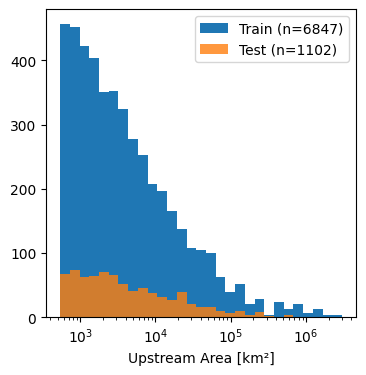

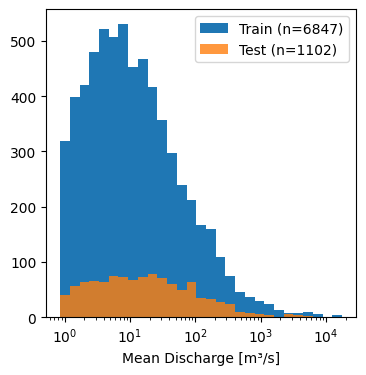

In [118]:
def train_test_hist(train, test, col, kwgs):
    fig, ax = plt.subplots(1, figsize=(4,4))
    data = outlets[col]
    bins = np.logspace(np.log10(data.min()), np.log10(data.max()), 30)
    
    ax.hist(train[col], bins=bins, label=f'Train (n={len(train)})')
    ax.hist(test[col], bins=bins, alpha=0.8, label=f'Test (n={len(test)})')
    ax.set_xlabel(kwgs.get('xlabel',''))
    plt.xscale('log')
    plt.legend()
    fig.show()
    return fig

train_basins = gauges[gauges['train']]
test_basins = gauges[~gauges['train']]

plot_cfg = {
    'total_area': {'xlabel':'Upstream Area [km²]'}, 
    'mean_discharge': {'xlabel':'Mean Discharge [m³/s]'}
}
for col, kwgs in plot_cfg.items():
    fig = train_test_hist(train_basins, test_basins, col, kwgs)
    fig.savefig(fig_dir / "train_test" / f"swot_hist_{col}.png", dpi=300)

In [22]:
from shapely.ops import unary_union
from shapely.geometry import Polygon, MultiPolygon
from tqdm import tqdm

basin_geoms = {}

for basin, row in tqdm(matchups.groupby('outlet_id')):
    geom = unary_union(row.geometry.envelope)
    basin_geoms[basin] = {'geometry': geom}

100%|██████████| 643/643 [00:01<00:00, 640.48it/s]


In [76]:
from shapely.ops import unary_union
from shapely.geometry import Polygon, MultiPolygon
from tqdm import tqdm

basin_geoms = {}

for basin, row in tqdm(matchups.groupby('outlet_id')):
    geom = unary_union(row.geometry.simplify(tolerance=0.001, preserve_topology=True))

    # Ensure validity (fix self-intersections, etc.)
    geom = geom.buffer(0)

    if isinstance(geom, Polygon):
        # Drop interior holes by recreating from exterior
        outline = Polygon(geom.exterior)
    elif isinstance(geom, MultiPolygon):
        # Combine all outer boundaries into one polygon
        exteriors = [Polygon(p.exterior) for p in geom.geoms]
        outline = unary_union(exteriors)
    else:
        raise TypeError(f"Unexpected geometry type: {type(geom)}")

    basin_geoms[basin] = {'geometry': outline}

100%|██████████| 233/233 [10:26<00:00,  2.69s/it]


In [127]:
basin_gdf = gpd.GeoDataFrame(basin_geoms).T
basin_gdf.set_geometry('geometry', inplace=True)
basin_gdf.set_crs('EPSG:4326',  inplace=True)
basin_gdf.to_crs('ESRI:53030',  inplace=True)

In [128]:
basin_gdf

,geometry
ABOM-12049010,"POLYGON ((12632794.784 -1853492.64, 12632656.4..."
ABOM-121206010,"POLYGON ((10844377.564 -2376532.438, 10843850...."
ABOM-122989010,"POLYGON ((11014727.175 -2301481.429, 11014763...."
ABOM-123864010,"POLYGON ((11552208.563 -2042407.192, 11551561...."
ABOM-128547010,"POLYGON ((11892051.352 -1988456.814, 11892018...."
...,...
USGS-15747000,"POLYGON ((-11365371.064 7081971.256, -11364637..."
USGS-15875000,"POLYGON ((-10981008.128 7139429.233, -10981529..."
USGS-15896000,"POLYGON ((-10301099.821 7168907.032, -10301891..."
USGS-15908000,"POLYGON ((-10304590.657 7131267.554, -10304107..."


outlet_id
ABOM-12049010     True
ABOM-121206010    True
ABOM-122989010    True
ABOM-123864010    True
ABOM-128547010    True
                  ... 
USGS-15747000     True
USGS-15875000     True
USGS-15896000     True
USGS-15908000     True
USGS-50059050     True
Name: train, Length: 233, dtype: bool

In [122]:
basins_gdf

NameError: name 'basins_gdf' is not defined

In [130]:
# basin_gdf['train'] = False
basin_gdf = basin_gdf.join(matchups.groupby('outlet_id')['train'].any())
basin_gdf

,geometry,train
ABOM-12049010,"POLYGON ((12632794.784 -1853492.64, 12632656.4...",True
ABOM-121206010,"POLYGON ((10844377.564 -2376532.438, 10843850....",True
ABOM-122989010,"POLYGON ((11014727.175 -2301481.429, 11014763....",True
ABOM-123864010,"POLYGON ((11552208.563 -2042407.192, 11551561....",True
ABOM-128547010,"POLYGON ((11892051.352 -1988456.814, 11892018....",True
...,...,...
USGS-15747000,"POLYGON ((-11365371.064 7081971.256, -11364637...",True
USGS-15875000,"POLYGON ((-10981008.128 7139429.233, -10981529...",True
USGS-15896000,"POLYGON ((-10301099.821 7168907.032, -10301891...",True
USGS-15908000,"POLYGON ((-10304590.657 7131267.554, -10304107...",True


train: 4207
test: 909


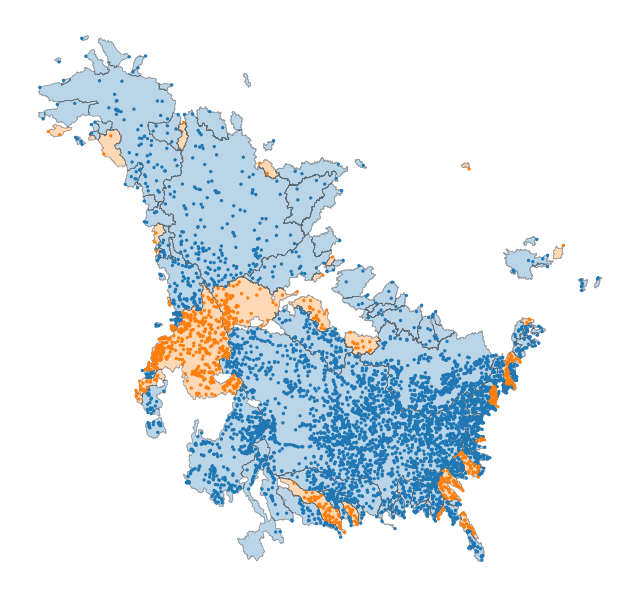

train: 1614
test: 118


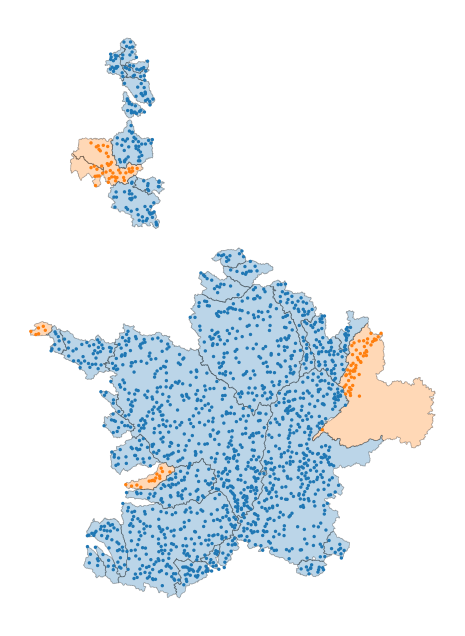

train: 1010
test: 75


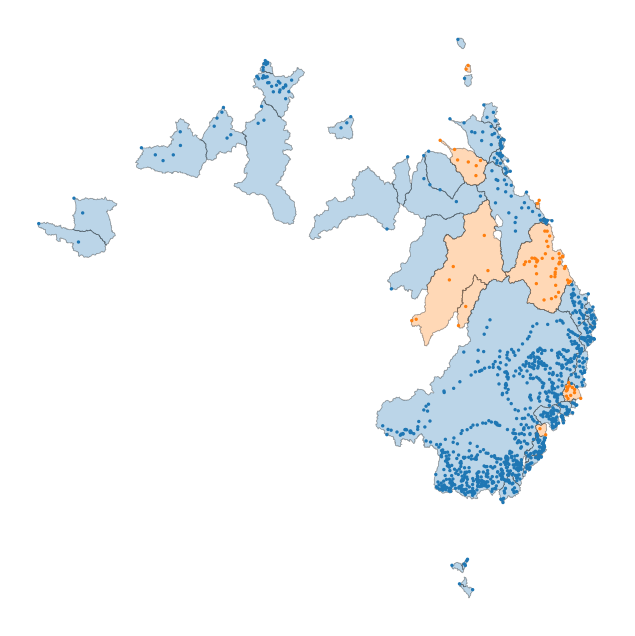

In [132]:
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
# Load and reproject to geographic
basins = basin_gdf.to_crs("EPSG:4326")
gauges = gauges.set_crs("EPSG:4326")

# Define region bounding boxes (roughly)
regions = {
    "NA": (-170, -50, 20, 85),   # lon_min, lon_max, lat_min, lat_max
    "EU": (-25, 60, 35, 75),
    "Australia": (110, 155, -45, -10)
}

# Define region-specific projections
region_crs = {
    "NA": "ESRI:102009",  # North America Lambert Conformal Conic
    "EU": "EPSG:3035",           # Europe LAEA
    "Australia": "EPSG:3577",        # Australia Albers
}


base_cmap = plt.cm.tab10  # or 'Set1', 'tab10', etc.
colors = base_cmap([0.1, 0.0])  # first two colors from the start
cmap = ListedColormap(colors)


# Plot each region
for name, bb  in regions.items():
    fig, ax = plt.subplots(1, figsize=(8,8))
    (lon_min, lon_max, lat_min, lat_max) = bb
    
    region_gdf = basins.cx[lon_min:lon_max, lat_min:lat_max].to_crs(region_crs[name])
    region_gauges = gauges.cx[lon_min:lon_max, lat_min:lat_max].to_crs(region_crs[name])
    print(f"train: {region_gauges['train'].sum()}")
    print(f"test: {(~region_gauges['train']).sum()}")
    
    # gdf_simp = gdf.copy()
    # gdf_simp.geometry = gdf.geometry.simplify(tolerance=1E3, preserve_topology=True)
    
    region_gdf.plot(column='train', cmap=cmap, alpha=0.3, edgecolor='black', linewidth=0.5, legend=False, ax=ax)
    region_gauges.plot(column='train', cmap=cmap, markersize=2, legend=False, ax=ax)
    ax.axis('off')
    plt.show()
    
    fig.savefig(
        fig_dir / 'train_test'/ f'{name}_swot.svg',
        transparent=True,
        bbox_inches='tight',
        pad_inches=0,
        format='svg'
    )


In [134]:
print(f"train: {gauges['train'].sum()}")
print(f"test: {(~gauges['train']).sum()}")

train: 6847
test: 1102


In [41]:
import evaluate
basin_m = evaluate.get_basin_metrics(results)

In [42]:
basin_m

Feature              discharge                                                \
Metric                 num_obs          R2         NSE        KGE       sigE   
21005508                     0         NaN         NaN        NaN        NaN   
21005509                     0         NaN         NaN        NaN        NaN   
21005513                     0         NaN         NaN        NaN        NaN   
21005546                     0         NaN         NaN        NaN        NaN   
21005554                     0         NaN         NaN        NaN        NaN   
...                        ...         ...         ...        ...        ...   
USGS-261543080495000      1555  -13.563363  -13.563363  -2.546601   2.827602   
USGS-261808081042800      1280   -4.378637   -4.378637  -1.028376   2.256396   
USGS-262038080584600      1603 -179.250717 -179.250717 -15.219277  16.798693   
USGS-50035000             1734   -0.067421   -0.067421  -0.527979   0.573083   
USGS-50037000             1737    0.031573    0.031573  -0.245735   0.387734   

Feature                                                                   \
Metric                      rRMSE         MAPE        nBias           RE   
21005508                      NaN          NaN          NaN          NaN   
21005509                      NaN          NaN          NaN          NaN   
21005513                      NaN          NaN          NaN          NaN   
21005546                      NaN          NaN          NaN          NaN   
21005554                      NaN          NaN          NaN          NaN   
...                           ...          ...          ...          ...   
USGS-261543080495000   120.220256   320.334673   153.982472   184.836984   
USGS-261808081042800    94.848114   1506.54192   222.100353   222.100353   
USGS-262038080584600   118.938255  6100.892258  2079.828262  2079.828072   
USGS-50035000         6674.198914    93.183839   -95.516789  2130.544853   
USGS-50037000           784.71384    59.627306   -55.725622   137.396383   

Feature                                      
Metric                         RB Agreement  
21005508                      NaN       NaN  
21005509                      NaN       NaN  
21005513                      NaN       NaN  
21005546                      NaN       NaN  
21005554                      NaN       NaN  
...                           ...       ...  
USGS-261543080495000   153.982449   0.22489  
USGS-261808081042800   222.100353  0.237957  
USGS-262038080584600  2079.828072  0.053001  
USGS-50035000        -2130.544853  0.015461  
USGS-50037000         -125.864244  0.083726  

[5238 rows x 11 columns]

In [47]:
import geopandas as gpd
save_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/reservoirs")
metadata_dir = save_dir / "metadata"
matchups = gpd.read_parquet(metadata_dir / "All_MERIT_matchups.parquet").set_index('comid')
matchups.index = matchups.index.astype(str)

In [50]:
list(matchups.dropna(subset='mean_discharge'))

['outlet',
 'outlet_id',
 'total_area',
 'unitarea',
 'reservoir',
 'custom',
 'reach_id',
 'sword_area',
 'sword_distance',
 'lake_reach_ids',
 'lake_pld_ids',
 's2m_values',
 'name',
 'area',
 'latitude',
 'longitude',
 'min_date',
 'max_date',
 'min_discharge',
 'max_discharge',
 'mean_discharge',
 'count_discharge',
 'provider',
 'hybas_area_diff',
 'geometry']

In [53]:
matchups

,outlet,outlet_id,total_area,unitarea,reservoir,custom,reach_id,sword_area,sword_distance,lake_reach_ids,...,longitude,min_date,max_date,min_discharge,max_discharge,mean_discharge,count_discharge,provider,hybas_area_diff,geometry
comid,,,,,,,,,,,,,,,,,,,,,
21000001,POINT (5.889166666666659 47.94916666666667),EAUF-V7200010,398.5,152.9,False,False,NaN,NaN,NaN,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,-0.034201,"MULTIPOLYGON (((5.93875 47.99125, 5.93708 47.9..."
21000012,POINT (5.889166666666659 47.94916666666667),EAUF-V7200010,324.8,194.6,False,False,NaN,NaN,NaN,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,0.053341,"MULTIPOLYGON (((5.79042 48.01125, 5.79042 48.0..."
21000019,POINT (5.684999999999993 47.53416666666667),EAUF-V7200010,5173.0,242.5,False,False,2.160280e+10,4530.071328,0.0,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,-0.007977,"MULTIPOLYGON (((5.76042 47.56125, 5.76042 47.5..."
21000021,POINT (5.76916666666666 47.58083333333334),EAUF-V7200010,4758.7,8.4,False,False,2.160280e+10,4278.612301,0.0,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,0.003021,"MULTIPOLYGON (((5.80625 47.60125, 5.80708 47.6..."
21000022,POINT (5.80416666666666 47.57),EAUF-V7200010,4506.6,68.9,False,False,2.160280e+10,4278.612301,0.0,[],...,NaN,NaT,NaT,NaN,NaN,NaN,NaN,None,0.009101,"MULTIPOLYGON (((5.85875 47.57458, 5.85875 47.5..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USGS-410401112134801,POINT (-112.1875 41.0625),USGS-410401112134801,9900.3,296.5,False,True,NaN,NaN,NaN,[],...,-112.230256,2003-10-01,2025-09-08,0.006230,45.873291,11.263905,7165.0,usgs,-0.002093,"MULTIPOLYGON (((-112.21458 40.96042, -112.2154..."
USGS-50035000,POINT (-66.4592 18.3217),USGS-50037000,345.7,345.7,False,True,NaN,NaN,NaN,[],...,-66.459568,1950-01-01,2025-09-08,0.240693,1857.585136,7.406389,25691.0,usgs,-0.091982,"MULTIPOLYGON (((-66.49208 18.29625, -66.49208 ..."
USGS-50037000,POINT (-66.5 18.3983),USGS-50037000,429.1,83.4,False,True,NaN,NaN,NaN,[],...,-66.496560,2019-06-13,2025-09-08,1.265763,911.802460,11.017469,2247.0,usgs,0.167805,"MULTIPOLYGON (((-66.50125 18.33125, -66.50125 ..."


In [146]:
with open(run_dir / 'results' / "test_metrics.pkl", 'rb') as f:
    bulk_m, basin_m = pickle.load(f)

bulk_m

{'discharge': {'num_obs': 2173546,
  'R2': 0.0004978775978088379,
  'NSE': 0.0004978775978088379,
  'KGE': -0.5863531826188011,
  'sigE': 0.0525627950206399,
  'rRMSE': 26177.334594726562,
  'MAPE': 739.8668766021729,
  'nBias': -33.27680826187134,
  'RE': 187.00129985809326,
  'RB': -49.87292289733887,
  'Agreement': 0.001126006567815696}}

In [148]:
basin_m['discharge']['NSE'].dropna().sort_values()

ABOM-573135010     -1277323.625
USGS-13095175     -392030.65625
USGS-12452550    -207472.234375
ECCC-08NJ026      -190402.65625
USGS-01636690     -53623.507812
                      ...      
USGS-14173500          0.796976
USGS-12414500           0.80865
EAUF-P7041510           0.81674
EAUF-J3821820          0.826521
ECCC-08HA011           0.843632
Name: NSE, Length: 1482, dtype: object

In [78]:
nse = basin_metrics['discharge']['NSE'].dropna().sort_values()
nse = nse[nse>-1]

nse

UKEA-F2560      -0.977399
USGS-13307000   -0.966887
ABOM-18556010   -0.960044
UKEA-1800TH     -0.946882
USGS-13057000   -0.945129
                   ...   
USGS-14173500    0.796976
USGS-12414500     0.80865
EAUF-P7041510     0.81674
EAUF-J3821820    0.826521
ECCC-08HA011     0.843632
Name: NSE, Length: 1152, dtype: object

In [128]:
df = results.xs(basin, level='subbasin').sort_index()
df = df.droplevel(0, axis=0)
df = df.droplevel(1, axis=1)
df

Type,obs,pred
date,,
2020-03-31,63.712894,65.077629
2020-04-01,59.182213,57.914429
2020-04-02,52.103004,54.109154
2020-04-03,46.722794,49.173328
2020-04-04,42.758438,44.027176
...,...,...
2024-12-27,34.829727,45.431370
2024-12-28,36.245567,45.562862
2024-12-29,44.740612,47.794735


In [180]:
run_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/cached_multigraph/era5_swot_20251009_012303")
results = pd.read_parquet(run_dir / 'results' / 'test_results.parquet')
with open(run_dir / 'results' / "test_metrics.pkl", 'rb') as f:
    bulk_m, basin_m = pickle.load(f)

bulk_m

{'discharge': {'num_obs': 2173546,
  'R2': 0.00043779611587524414,
  'NSE': 0.00043779611587524414,
  'KGE': -0.5706979749030652,
  'sigE': 0.051239379420876516,
  'rRMSE': 23070.220947265625,
  'MAPE': 973.8686561584473,
  'nBias': -19.401532411575317,
  'RE': 157.52058029174805,
  'RB': -24.071848392486572,
  'Agreement': 0.0012494069288463416}}

In [179]:
e_run_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/cached_multigraph/era5_20251009_012244")
e_results = pd.read_parquet(e_run_dir / 'results' / 'test_results.parquet')
with open(e_run_dir / 'results' / "test_metrics.pkl", 'rb') as f:
    e_bulk_m, e_basin_m = pickle.load(f)

e_bulk_m

{'discharge': {'num_obs': 2173546,
  'R2': 0.00045943260192871094,
  'NSE': 0.00045943260192871094,
  'KGE': -0.5215163819771897,
  'sigE': 0.05297123156487946,
  'rRMSE': 16662.347412109375,
  'MAPE': 1429.9579620361328,
  'nBias': -13.324455916881561,
  'RE': 157.4047327041626,
  'RB': -15.372788906097412,
  'Agreement': 0.00171713113742189}}

In [183]:
nse = basin_m['discharge']['NSE']
e_nse = e_basin_m['discharge']['NSE']

nse.dropna().sort_values()

ABOM-573135010    -1278564.375
USGS-12452550       -1104033.0
ECCC-08NJ026      -367465.1875
USGS-14211820    -268791.71875
USGS-14211550     -248220.9375
                      ...     
ECCC-01BE001          0.816836
ECCC-08NK002          0.819847
USGS-14165000         0.823526
EAUF-P6382510         0.823693
USGS-13317000         0.861924
Name: NSE, Length: 1482, dtype: object

In [198]:
mask = (nse>-1) & (e_nse>-1)

In [199]:
dnse = (nse[mask] - e_nse[mask])

In [200]:
dnse.sort_values()

USGS-13135500   -1.692654
UKEA-2024       -1.680984
ECCC-05AA027    -1.588797
ABOM-9449010    -1.575208
UKEA-2057       -1.382402
                   ...   
ECCC-05BH005     1.197477
UKEA-037007      1.378338
EAUF-J0121510    1.648299
USGS-13317000    1.726741
USGS-13302500    1.737098
Name: NSE, Length: 1025, dtype: object

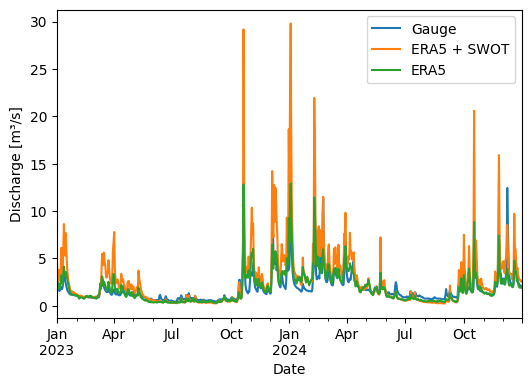

In [209]:
basin = 'UKEA-2024'

df = results.xs(basin, level='subbasin').sort_index()
df = df.droplevel(0, axis=0)
df = df.droplevel(1, axis=1)
df = df[df.index > pd.Timestamp('2022-12-31')]

e_df = e_results.xs(basin, level='subbasin').sort_index()
e_df = e_df.droplevel(0, axis=0)
e_df = e_df.droplevel(1, axis=1)
e_df = e_df[e_df.index > pd.Timestamp('2022-12-31')]

fig, ax = plt.subplots(1,1, figsize=(6,4))
df['obs'].plot(ax=ax, label='Gauge')
df['pred'].plot(ax=ax, label='ERA5 + SWOT')
e_df['pred'].plot(ax=ax, label='ERA5')

plt.legend()
ax.set_ylabel('Discharge [m³/s]')
ax.set_xlabel('Date')
plt.show()
fig.savefig(run_dir / 'figures' / f"timeseries_{basin}.png", dpi=300)

In [71]:
basin

'USGS-12414500'

In [161]:
results['obs']['discharge'].dropna()

basin           subbasin        date      
USGS-02428400   USGS-02379500   2023-01-14     9.571094
                USGS-02380500   2023-01-14    20.501396
                USGS-02382500   2023-01-14    57.483185
                USGS-02383500   2023-01-14    92.312935
                USGS-02384500   2023-01-14    35.396057
                                                ...    
USGS-01589035   USGS-01589035   2020-07-26     2.038813
ABOM-281030010  ABOM-281030010  2023-03-24     0.094000
ABOM-224727010  ABOM-224727010  2024-03-01     0.006000
ABOM-132541010  ABOM-132541010  2024-02-02     4.341001
USGS-12048000   USGS-12048000   2021-08-20     3.737824
Name: discharge, Length: 2173546, dtype: float32

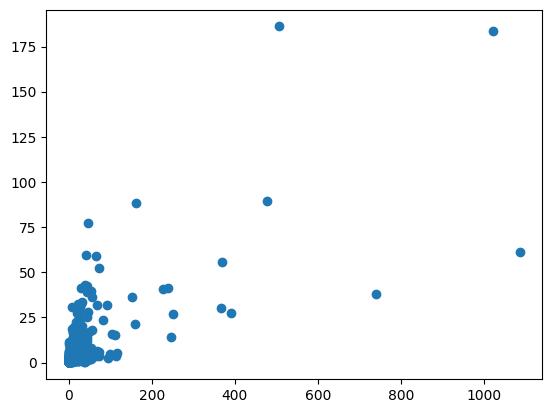

In [30]:
plt.scatter(df['obs']['discharge'], df['pred']['discharge'])

In [24]:
import pickle
with open(results_dir / "test_metrics.pkl", 'rb') as f:
    bulk_m, basin_m = pickle.load(f)

bulk_m

{'discharge': {'num_obs': 108385,
  'R2': -0.02997457981109619,
  'MAPE': 427.0320415496826,
  'nBias': -0.05712399142794311,
  'RE': 232.67614841461182,
  'RB': -0.05716085433959961,
  'qRE': array([ 73.60065994, 232.67614947, 654.88286463]),
  'qnBias': array([-6.98563695e+01, -5.71239914e-02,  2.33670533e+02]),
  'MAE': 53.644592,
  'RMSE': 194.12527,
  'rRMSE': 1688.498306274414,
  'KGE': -0.3831915309608416,
  'NSE': -0.02997457981109619,
  'Agreement': 0.029437440800148096}}

In [35]:
targets = list(bulk_m.keys())

In [ ]:
import geopandas as gpd
proj_dir = Path("/nas/cee-water/cjgleason/ted/swot-ml/data/distributed")
metadata_dir = proj_dir / "metadata"
basins = gpd.read_file(metadata_dir / 'matchups.geojson').set_index("HYBAS_ID")
basins.index = basins.index.astype(str)
basins

In [ ]:
import evaluate
pred = evaluate.predict(trainer.model, dataloader, denormalize=False)

In [ ]:
pred

In [ ]:
x = pred.xs('2021-02-08', level='date')


x['pred']['discharge']

In [ ]:
x['pred']['discharge'].hist()

In [ ]:
basins_pred = basins.merge(x['pred']['discharge'], left_index=True, right_index=True)
basins_pred.plot('discharge')

In [ ]:
plt.scatter(x['obs']['discharge'], x['pred']['discharge'])
# plt.plot([0,500], [0,500], 'r--')